# Telco Customer Churn — Prediction Model

## Objective

The goal of this notebook is to build a machine learning model that predicts whether a customer is likely to churn.

This notebook focuses on:

- preparing the data for modeling
- encoding categorical variables
- splitting the data into training and test sets
- training classification models
- evaluating model performance
- identifying the most important churn drivers

The purpose is not only to predict churn, but also to help the business identify high-risk customers before they leave.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Cleaned Dataset

In [3]:
df = pd.read_csv("../data/telco_churn_cleaned.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,TenureGroup,MonthlyChargesGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High


## Dataset Overview

We inspect the cleaned dataset before preparing it for modeling.

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (7032, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   gender               7032 non-null   object 
 2   SeniorCitizen        7032 non-null   int64  
 3   Partner              7032 non-null   object 
 4   Dependents           7032 non-null   object 
 5   tenure               7032 non-null   int64  
 6   PhoneService         7032 non-null   object 
 7   MultipleLines        7032 non-null   object 
 8   InternetService      7032 non-null   object 
 9   OnlineSecurity       7032 non-null   object 
 10  OnlineBackup         7032 non-null   object 
 11  DeviceProtection     7032 non-null   object 
 12  TechSupport          7032 non-null   object 
 13  StreamingTV          7032 non-null   object 
 14  StreamingMovies      7032 non-null   object 
 15  Contract            

## Target Variable

The target variable is `Churn_Flag`, where:

- `1` = customer churned
- `0` = customer stayed

In [5]:
df["Churn_Flag"].value_counts()

Churn_Flag
0    5163
1    1869
Name: count, dtype: int64

## Remove Non-Predictive Identifier

The `customerID` column is only an identifier and should not be used as a predictive feature.

In [6]:
df_model = df.drop(columns=["customerID"]).copy()
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,TenureGroup,MonthlyChargesGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High


## Separate Features and Target

We separate the target variable from the input features.

In [7]:
X = df_model.drop(columns=["Churn", "Churn_Flag"])
y = df_model["Churn_Flag"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (7032, 21)
Target vector shape: (7032,)


## Encode Categorical Variables

Machine learning models require numeric inputs, so categorical variables are converted using one-hot encoding.

In [8]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 months,TenureGroup_25-48 months,TenureGroup_49-72 months,MonthlyChargesGroup_Low,MonthlyChargesGroup_Medium,MonthlyChargesGroup_Very High
0,0,1,29.85,29.85,False,True,False,False,True,False,...,True,False,True,False,False,False,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,True,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,True,False,False,True,False,False,False,False,True,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,False


## Train-Test Split

We split the data into training and test sets so that model performance can be evaluated on unseen data.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 36)
X_test shape: (1407, 36)
y_train shape: (5625,)
y_test shape: (1407,)


## Feature Scaling for Logistic Regression

Logistic Regression performs better when numeric features are scaled.

We scale the training and test data separately to avoid data leakage.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model 1 — Logistic Regression

We begin with Logistic Regression because it is a strong and interpretable baseline for binary classification problems.

In [11]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

## Logistic Regression Performance

In [12]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy: {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall: {log_recall:.4f}")
print(f"F1-score: {log_f1:.4f}")
print(f"ROC-AUC: {log_auc:.4f}")

Accuracy: 0.7925
Precision: 0.6323
Recall: 0.5241
F1-score: 0.5731
ROC-AUC: 0.8347


These metrics show how well the model distinguishes between customers who churn and those who stay.

In [13]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



## Logistic Regression Confusion Matrix

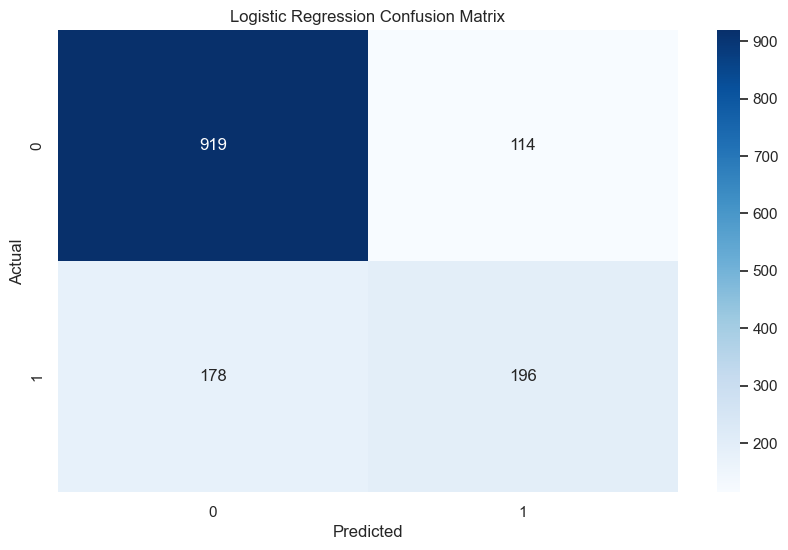

In [14]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows how many churn cases and non-churn cases were classified correctly and incorrectly.

## Baseline Model 2 — Random Forest

We also train a Random Forest model to compare performance with a more flexible non-linear model.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## Random Forest Performance

In [16]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")

Accuracy: 0.7918
Precision: 0.6392
Recall: 0.4973
F1-score: 0.5594
ROC-AUC: 0.8337


In [17]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Random Forest Confusion Matrix

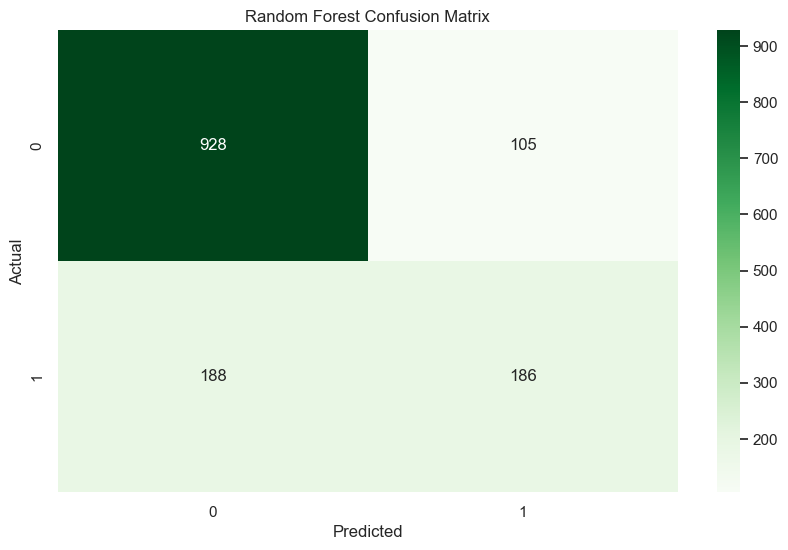

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison

We compare both models across key performance metrics.

In [19]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1],
    "ROC-AUC": [log_auc, rf_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.792466,0.632258,0.524064,0.573099,0.834681
1,Random Forest,0.791756,0.639175,0.497326,0.559398,0.833711


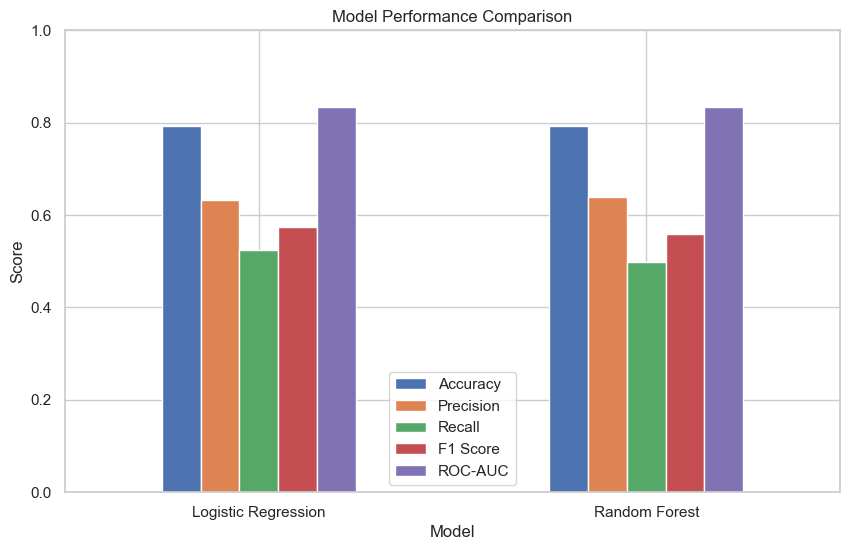

In [20]:
comparison.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

This comparison helps identify which model offers the best balance between accuracy and churn detection performance.

## ROC Curve Comparison

The ROC curve helps compare the trade-off between true positive rate and false positive rate across models.

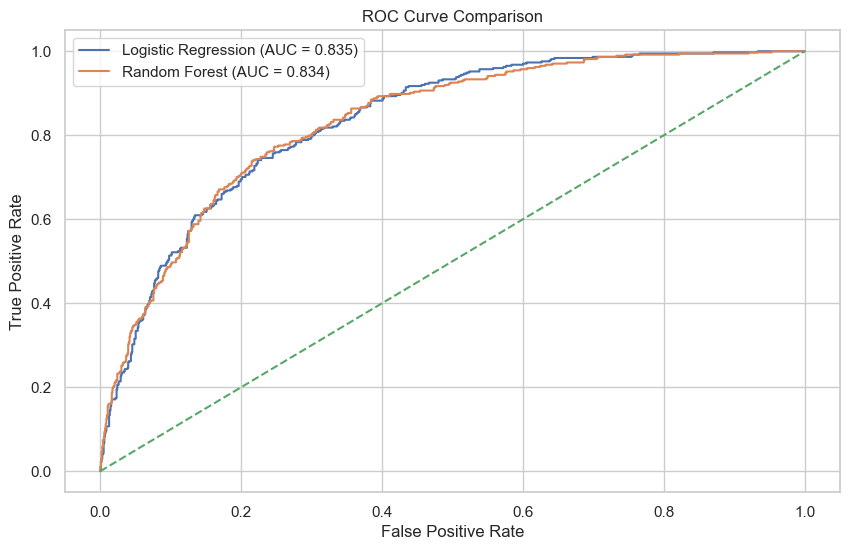

In [21]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

A model with a higher ROC-AUC has better overall ability to distinguish churners from non-churners.

## Feature Importance — Random Forest

Random Forest provides feature importance scores that help identify the strongest churn predictors.

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.180339
3,TotalCharges,0.149946
2,MonthlyCharges,0.115926
10,InternetService_Fiber optic,0.064863
28,PaymentMethod_Electronic check,0.051893
25,Contract_Two year,0.049209
32,TenureGroup_49-72 months,0.035955
24,Contract_One year,0.028469
13,OnlineSecurity_Yes,0.028346
19,TechSupport_Yes,0.023456


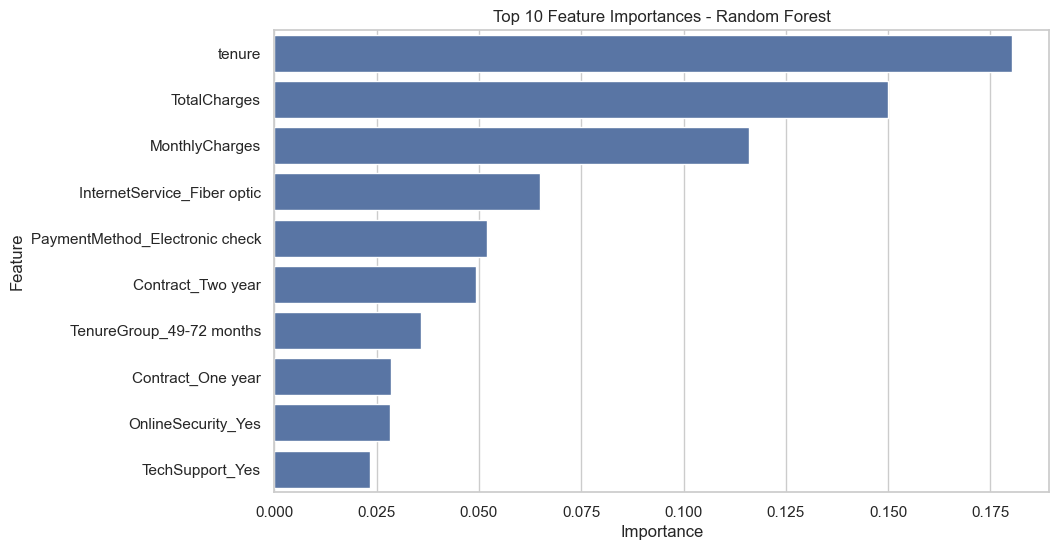

In [23]:
top_features = feature_importance.head(10)

sns.barplot(data=top_features, y="Feature", x="Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The most important variables provide insight into the factors most strongly associated with churn risk.

## Logistic Regression Coefficients

Because Logistic Regression is interpretable, we can also inspect which variables push churn risk up or down.

In [24]:
log_coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

log_coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.734871
3,TotalCharges,0.292297
32,TenureGroup_49-72 months,0.254678
21,StreamingTV_Yes,0.247408
9,MultipleLines_Yes,0.233436
23,StreamingMovies_Yes,0.230479
28,PaymentMethod_Electronic check,0.176033
26,PaperlessBilling_Yes,0.144083
17,DeviceProtection_Yes,0.080829
0,SeniorCitizen,0.075329


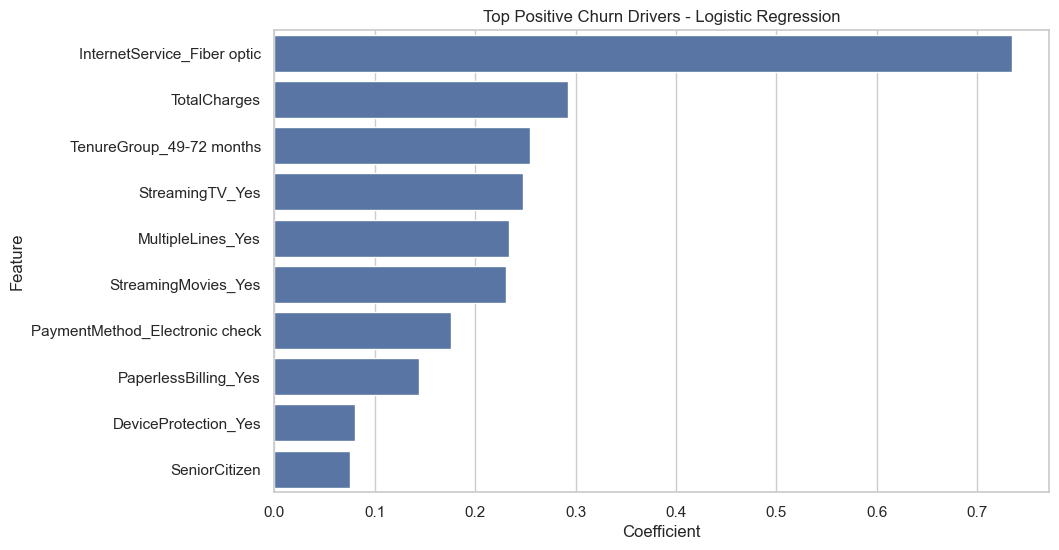

In [25]:
top_positive = log_coefficients.head(10)

sns.barplot(data=top_positive, y="Feature", x="Coefficient")
plt.title("Top Positive Churn Drivers - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Positive coefficients indicate variables associated with higher churn probability.

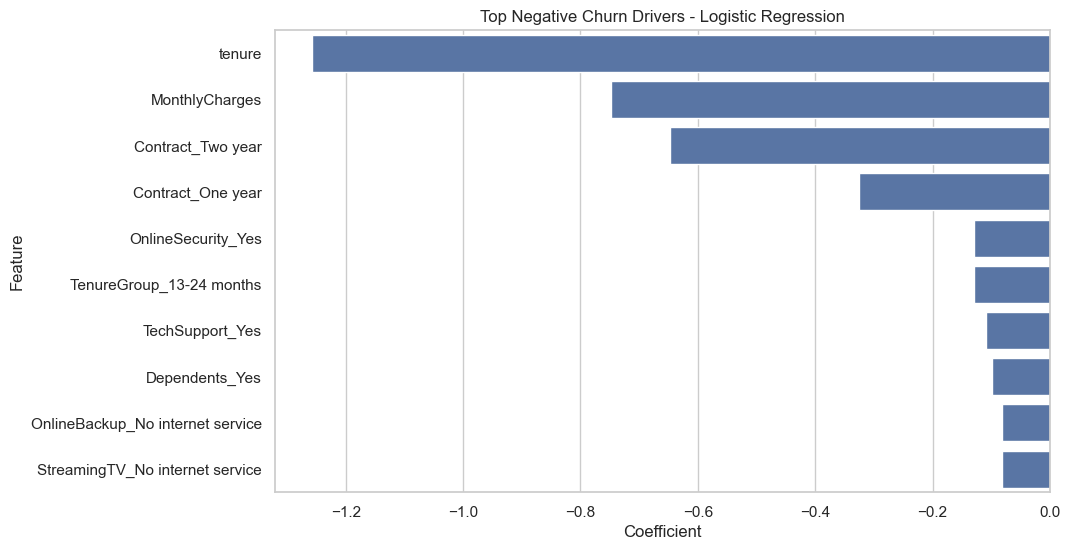

In [26]:
top_negative = log_coefficients.sort_values(by="Coefficient", ascending=True).head(10)

sns.barplot(data=top_negative, y="Feature", x="Coefficient")
plt.title("Top Negative Churn Drivers - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Negative coefficients indicate variables associated with lower churn probability.

## Predict Churn Probability for Test Customers

We generate predicted churn probabilities for the test set to identify high-risk customers.

In [27]:
predictions = X_test.copy()
predictions["Actual_Churn"] = y_test.values
predictions["Predicted_Churn"] = y_pred_rf
predictions["Churn_Probability"] = y_prob_rf

predictions.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,PaymentMethod_Mailed check,TenureGroup_13-24 months,TenureGroup_25-48 months,TenureGroup_49-72 months,MonthlyChargesGroup_Low,MonthlyChargesGroup_Medium,MonthlyChargesGroup_Very High,Actual_Churn,Predicted_Churn,Churn_Probability
971,0,59,75.95,4542.35,False,True,True,True,False,False,...,False,False,False,True,False,False,False,0,0,0.010677
618,0,7,78.55,522.95,False,False,False,True,False,True,...,False,False,False,False,False,False,False,0,1,0.679645
4282,0,54,20.10,1079.45,False,False,False,True,False,False,...,True,False,False,True,True,False,False,0,0,0.016201
3715,0,2,20.65,38.70,False,False,False,True,False,False,...,True,False,False,False,True,False,False,1,0,0.088080
4525,0,71,105.15,7555.00,False,True,False,True,False,True,...,False,False,False,True,False,False,True,0,0,0.142826


## Top High-Risk Customers in Test Set

In [28]:
high_risk_customers = predictions.sort_values(by="Churn_Probability", ascending=False).head(10)
high_risk_customers[["Actual_Churn", "Predicted_Churn", "Churn_Probability"]]

,Actual_Churn,Predicted_Churn,Churn_Probability
3374,1,1,0.909216
807,1,1,0.893810
3676,1,1,0.888271
1726,1,1,0.888093
2922,0,1,0.887619
1734,1,1,0.887619
2602,1,1,0.877894
2895,1,1,0.873998
3721,1,1,0.873755
2626,1,1,0.870349


These are the customers the model identifies as having the highest probability of churn.

In a real business context, this list could be used for proactive retention campaigns.

## Business Interpretation

A churn prediction model can help the company move from reactive analysis to proactive retention.

Instead of only studying past churn, the company can identify high-risk customers in advance and target them with retention actions such as:

- contract upgrade incentives
- pricing offers
- support bundles
- proactive outreach from customer success teams

## Final Insights

The predictive analysis shows that:

1. churn can be predicted with meaningful accuracy
2. customer churn is influenced by a combination of contract structure, pricing, tenure, and service features
3. interpretable models such as Logistic Regression help explain churn drivers
4. stronger models such as Random Forest can improve predictive power
5. churn prediction can support targeted business intervention before revenue is lost

## Conclusion

This notebook demonstrates that customer churn is not only explainable after the fact, but also predictable in advance.

A predictive model allows the business to identify customers at high risk of leaving and to design targeted retention strategies before churn happens.

Combined with the business and financial analysis, this model strengthens the overall value of the project by adding a forward-looking decision-making component.